# Electricity Forecasting Model Comparison

Implementation notebook to compare:
- Operational baseline (`total load forecast`)
- SARIMA
- SARIMAX
- ML hybrid (SARIMA + XGBoost on residuals)
- TimeXer

Main goal:
- Evaluate performance with a rolling scheme configurable by `H_ROLL` (hours)
- Compare global $R^2$ and hourly $R^2$
- Visualize whether models improve or worsen versus the operational baseline

## 1. Set Up Python Environment and Imports

Defines imports, plotting style, seed, and global experiment constants.

In [1]:
# Optional install (uncomment if needed)
# %pip install -q timexer neuralforecast torch xgboost

import warnings
import random
import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression

from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)

DATA_DIR = "data/archive"
ENERGY_PATH = f"{DATA_DIR}/energy_dataset.csv"
WEATHER_PATH = f"{DATA_DIR}/weather_features.csv"

TARGET_COL = "total load actual"
BASELINE_COL = "total load forecast"
TIME_COL = "time"

# Rolling horizon in hours (user-controlled)
H_ROLL = 24
FAST_MODE = True  # True: faster iteration, False: full-range run

print("Setup complete")
print(f"H_ROLL={H_ROLL}, FAST_MODE={FAST_MODE}")

Setup complete
H_ROLL=24, FAST_MODE=True


## 2. Load and Inspect Electricity Consumption Data

Load energy and weather data, then inspect shapes, date ranges, and available columns.

In [2]:
energy = pd.read_csv(ENERGY_PATH, parse_dates=[TIME_COL])
weather = pd.read_csv(WEATHER_PATH, parse_dates=["dt_iso"])

energy[TIME_COL] = pd.to_datetime(energy[TIME_COL], utc=True)
energy = energy.sort_values(TIME_COL).set_index(TIME_COL)

weather["dt_iso"] = pd.to_datetime(weather["dt_iso"], utc=True)
weather = weather.sort_values("dt_iso")

print(f"Energy shape:  {energy.shape}")
print(f"Weather shape: {weather.shape}")
print(f"Energy range: {energy.index.min()} -> {energy.index.max()}")
print(f"Target nulls: {energy[TARGET_COL].isna().sum()}")
print(f"Baseline nulls: {energy[BASELINE_COL].isna().sum()}")

display(energy.head(3))
display(weather.head(3))

Energy shape:  (35064, 28)
Weather shape: (178396, 17)
Energy range: 2014-12-31 23:00:00+00:00 -> 2018-12-31 22:00:00+00:00
Target nulls: 36
Baseline nulls: 0


,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
time,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2014-12-31 23:00:00+00:00,Valencia,270.475000,270.475000,270.475000,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
35145,2014-12-31 23:00:00+00:00,Madrid,267.325000,267.325000,267.325000,971,63,1,309,0.0,0.0,0.0,0,800,clear,sky is clear,01n
71412,2014-12-31 23:00:00+00:00,Bilbao,269.657312,269.657312,269.657312,1036,97,0,226,0.0,0.0,0.0,0,800,clear,sky is clear,01


## 3. Clean Missing Values and Parse Time Features

Merge with weather averages per timestamp, clean missing/duplicate values, and build calendar + lag features.

In [3]:
weather_num_cols = ["temp", "humidity", "wind_speed", "pressure", "clouds_all", "rain_1h"]
weather_avg = (
    weather.groupby("dt_iso")[weather_num_cols]
    .mean()
    .rename_axis(TIME_COL)
)

# Start from a clean copy and align all timestamps on the energy index
full_df = energy.copy()
full_df[TARGET_COL] = full_df[TARGET_COL].interpolate(method="time")
full_df = full_df[~full_df.index.duplicated(keep="first")].sort_index()

full_df = full_df.join(weather_avg, how="left")
full_df[weather_num_cols] = full_df[weather_num_cols].interpolate(method="time").ffill().bfill()
full_df["temp_c"] = full_df["temp"] - 273.15

# Calendar features
full_df["hour"] = full_df.index.hour
full_df["dayofweek"] = full_df.index.dayofweek
full_df["month"] = full_df.index.month
full_df["is_weekend"] = (full_df["dayofweek"] >= 5).astype(int)

# Lag features for ML and hybrid models
for lag in [1, 24, 48, 168]:
    full_df[f"lag_{lag}"] = full_df[TARGET_COL].shift(lag)

for window in [24, 168]:
    full_df[f"roll_mean_{window}"] = full_df[TARGET_COL].shift(1).rolling(window=window).mean()
    full_df[f"roll_std_{window}"] = full_df[TARGET_COL].shift(1).rolling(window=window).std()

print("Merged dataset shape:", full_df.shape)
print("Missing by key columns:")
display(full_df[[TARGET_COL, BASELINE_COL, "temp_c", "lag_24", "roll_mean_24"]].isna().sum())

Merged dataset shape: (35064, 47)
Missing by key columns:


total load actual       0
total load forecast     0
temp_c                  0
lag_24                 24
roll_mean_24           24
dtype: int64

## 4. Build Baseline Feature Matrix and Target

Define matrices for baseline ML and exogenous variables for SARIMAX.

In [4]:
ml_feature_cols = [
    "hour", "dayofweek", "month", "is_weekend",
    "temp_c", "humidity", "wind_speed", "pressure", "clouds_all", "rain_1h",
    "lag_1", "lag_24", "lag_48", "lag_168",
    "roll_mean_24", "roll_std_24", "roll_mean_168", "roll_std_168",
]

sarimax_exog_cols = ["temp_c", "humidity", "wind_speed", "generation wind onshore", "hour", "dayofweek"]
sarimax_exog_cols = [c for c in sarimax_exog_cols if c in full_df.columns]

model_df = full_df.dropna(subset=[TARGET_COL] + ml_feature_cols).copy()

print("Model dataframe shape:", model_df.shape)
print("ML features:", len(ml_feature_cols))
print("SARIMAX exog:", sarimax_exog_cols)
display(model_df[[TARGET_COL] + ml_feature_cols[:8]].head(3))

Model dataframe shape: (34896, 47)
ML features: 18
SARIMAX exog: ['temp_c', 'humidity', 'wind_speed', 'generation wind onshore', 'hour', 'dayofweek']


,total load actual,hour,dayofweek,month,is_weekend,temp_c,humidity,wind_speed,pressure
time,,,,,,,,,
2015-01-07 23:00:00+00:00,26788.0,23,2,1,0,3.452731,85.4,1.6,1020.6
2015-01-08 00:00:00+00:00,25146.0,0,3,1,0,3.063500,85.4,1.6,1020.8
2015-01-08 01:00:00+00:00,23889.0,1,3,1,0,2.631331,86.8,1.8,1021.0


## 5. Train/Test Split with Time-Aware Strategy

Strict chronological split to avoid leakage, with optional validation and fast mode.

In [5]:
if FAST_MODE:
    work_df = model_df.loc["2017-01-01":].copy()
else:
    work_df = model_df.copy()

# Chronological split: 70% train, 15% validation, 15% test
n = len(work_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = work_df.iloc[:train_end].copy()
val_df = work_df.iloc[train_end:val_end].copy()
test_df = work_df.iloc[val_end:].copy()

print(f"Train: {train_df.shape}, {train_df.index.min()} -> {train_df.index.max()}")
print(f"Val:   {val_df.shape}, {val_df.index.min()} -> {val_df.index.max()}")
print(f"Test:  {test_df.shape}, {test_df.index.min()} -> {test_df.index.max()}")

Train: (12263, 47), 2017-01-01 00:00:00+00:00 -> 2018-05-26 22:00:00+00:00
Val:   (2628, 47), 2018-05-26 23:00:00+00:00 -> 2018-09-13 10:00:00+00:00
Test:  (2628, 47), 2018-09-13 11:00:00+00:00 -> 2018-12-31 22:00:00+00:00


## 6. Train a Baseline Regression Model

Simple ML baseline using preprocessing pipeline + linear regression as an additional reference (besides the operational forecast).

In [28]:
X_train = train_df[ml_feature_cols]
y_train = train_df[TARGET_COL]
X_val = val_df[ml_feature_cols]
y_val = val_df[TARGET_COL]
X_test = test_df[ml_feature_cols]
y_test = test_df[TARGET_COL]

# In-sample series used for MASE denominator (seasonal naive, m=24)
MASE_INSAMPLE = pd.concat([y_train, y_val]).sort_index()

num_features = X_train.columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            num_features,
        )
    ],
    remainder="drop",
)

baseline_ml = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression()),
    ]
)

baseline_ml.fit(X_train, y_train)
pred_baseline_ml = pd.Series(baseline_ml.predict(X_test), index=y_test.index, name="Baseline_ML")
print("Baseline ML trained")

Baseline ML trained


## 7. Evaluate Model with Core Metrics

Common metric functions and hourly evaluation logic for all models.

In [29]:
def evaluate_predictions(
    y_true: pd.Series,
    y_pred: pd.Series,
    model_name: str,
    insample: pd.Series | None = None,
    seasonal_period: int = 24,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    aligned = pd.concat([y_true.rename("y_true"), y_pred.rename("y_pred")], axis=1).dropna()
    aligned["hour"] = aligned.index.hour

    # Use provided in-sample data for MASE scaling (preferred);
    # fallback to global variable or current y_true if unavailable.
    if insample is None:
        insample = globals().get("MASE_INSAMPLE", None)
    if insample is None:
        insample = aligned["y_true"]

    insample = pd.Series(insample).dropna()

    if len(insample) > seasonal_period:
        mase_scale = np.mean(np.abs(insample.iloc[seasonal_period:].values - insample.iloc[:-seasonal_period].values))
    elif len(insample) > 1:
        mase_scale = np.mean(np.abs(np.diff(insample.values)))
    else:
        mase_scale = np.nan

    mae_global = mean_absolute_error(aligned["y_true"], aligned["y_pred"])
    mase_global = mae_global / mase_scale if (pd.notna(mase_scale) and mase_scale > 0) else np.nan

    global_metrics = pd.DataFrame(
        {
            "model": [model_name],
            "MAE": [mae_global],
            "RMSE": [np.sqrt(mean_squared_error(aligned["y_true"], aligned["y_pred"]))],
            "R2": [r2_score(aligned["y_true"], aligned["y_pred"])],
            "MASE": [mase_global],
            "n_obs": [len(aligned)],
        }
    )

    hourly_rows = []
    for h, g in aligned.groupby("hour"):
        if len(g) < 5:
            continue
        mae_h = mean_absolute_error(g["y_true"], g["y_pred"])
        mase_h = mae_h / mase_scale if (pd.notna(mase_scale) and mase_scale > 0) else np.nan
        hourly_rows.append(
            {
                "model": model_name,
                "hour": h,
                "R2": r2_score(g["y_true"], g["y_pred"]),
                "MAE": mae_h,
                "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
                "MASE": mase_h,
                "n_obs": len(g),
            }
        )
    hourly_metrics = pd.DataFrame(hourly_rows)
    return global_metrics, hourly_metrics


def _force_datetime_freq(obj: pd.Series | pd.DataFrame, freq: str) -> pd.Series | pd.DataFrame:
    """Ensure a DatetimeIndex carries an explicit frequency required by statsmodels append."""
    out = obj.copy()
    idx = pd.DatetimeIndex(out.index)

    try:
        out.index = pd.DatetimeIndex(idx, freq=freq)
    except ValueError:
        # Fallback for slices where pandas drops freq metadata.
        rebuilt = pd.date_range(start=idx[0], periods=len(idx), freq=freq, tz=idx.tz)
        out.index = rebuilt

    return out


def _clean_exog(exog: pd.DataFrame) -> pd.DataFrame:
    """Remove inf and impute missing exogenous values for stable SARIMAX fitting."""
    x = exog.copy()
    x = x.replace([np.inf, -np.inf], np.nan)
    x = x.ffill().bfill()

    # Final safeguard if a column is entirely NaN in the selected window.
    for c in x.columns:
        if x[c].isna().any():
            med = x[c].median()
            if pd.isna(med):
                med = 0.0
            x[c] = x[c].fillna(med)

    return x


def rolling_forecast_sarimax(
    train_y: pd.Series,
    test_y: pd.Series,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 24),
    train_exog: pd.DataFrame | None = None,
    test_exog: pd.DataFrame | None = None,
    h_roll: int = 24,
) -> pd.Series:
    """Block rolling forecast; after each block the true observations are appended to update state."""
    train_y = train_y.sort_index()
    test_y = test_y.sort_index()

    inferred = pd.infer_freq(train_y.index)
    freq = inferred if inferred is not None else "h"

    train_y_f = _force_datetime_freq(train_y, freq)
    test_y_f = _force_datetime_freq(test_y, freq)

    if train_exog is not None:
        train_exog = _force_datetime_freq(train_exog.sort_index(), freq)
        train_exog = _clean_exog(train_exog)
    if test_exog is not None:
        test_exog = _force_datetime_freq(test_exog.sort_index(), freq)
        test_exog = _clean_exog(test_exog)

    res = SARIMAX(
        train_y_f,
        exog=train_exog,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

    preds = []

    for start in range(0, len(test_y_f), h_roll):
        end = min(start + h_roll, len(test_y_f))
        steps = end - start

        exog_block = None if test_exog is None else test_exog.iloc[start:end]
        fcst = res.get_forecast(steps=steps, exog=exog_block)
        pred_block = fcst.predicted_mean

        idx_block = test_y_f.index[start:end]
        pred_block.index = idx_block
        preds.append(pred_block)

        # Append observed true block to keep rolling update causal
        y_block = test_y_f.iloc[start:end]
        y_block = _force_datetime_freq(y_block, freq)
        if exog_block is not None:
            exog_block = _force_datetime_freq(exog_block, freq)
            exog_block = _clean_exog(exog_block)

        res = res.append(y_block, exog=exog_block, refit=False)

    pred_series = pd.concat(preds)
    pred_series = pred_series.reindex(test_y_f.index)
    pred_series.name = "rolling_pred"
    return pred_series

In [30]:
results_global = []
results_hourly = []
predictions = {}

# Operational baseline from dataset
pred_baseline_oper = test_df[BASELINE_COL].copy().rename("Baseline_Operative")

for name, pred in {
    "Baseline_Operative": pred_baseline_oper,
    "Baseline_ML": pred_baseline_ml,
}.items():
    gm, hm = evaluate_predictions(y_test, pred, name)
    results_global.append(gm)
    results_hourly.append(hm)
    predictions[name] = pred

display(pd.concat(results_global, ignore_index=True).sort_values("R2", ascending=False))

,model,MAE,RMSE,R2,MASE,n_obs
0,Baseline_Operative,243.145738,331.637253,0.994797,0.097896,2628
1,Baseline_ML,900.028652,1183.183639,0.933771,0.362372,2628


## 8. SARIMA, SARIMAX, Hybrid ML, and TimeXer

Training and evaluation under the same rolling protocol with `H_ROLL`.

In [31]:
# SARIMA (without exogenous variables)
start = time.time()

# Use train + validation as contiguous history before forecasting test
y_hist = pd.concat([y_train, y_val]).sort_index()

pred_sarima = rolling_forecast_sarimax(
    train_y=y_hist,
    test_y=y_test,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 24),
    train_exog=None,
    test_exog=None,
    h_roll=H_ROLL,
)
pred_sarima.name = "SARIMA"

gm, hm = evaluate_predictions(y_test, pred_sarima, "SARIMA")
gm["runtime_sec"] = time.time() - start
results_global.append(gm)
results_hourly.append(hm)
predictions["SARIMA"] = pred_sarima

print("SARIMA done")
display(gm)

SARIMA done


,model,MAE,RMSE,R2,MASE,n_obs,runtime_sec
0,SARIMA,1414.30448,2155.922582,0.780109,0.569431,2628,398.584939


In [32]:
# SARIMAX (with exogenous variables)
start = time.time()

# Use train + validation as contiguous history before forecasting test
y_hist = pd.concat([y_train, y_val]).sort_index()
train_exog_hist = pd.concat(
    [train_df[sarimax_exog_cols], val_df[sarimax_exog_cols]],
    axis=0,
).sort_index()
test_exog = test_df[sarimax_exog_cols]

pred_sarimax = rolling_forecast_sarimax(
    train_y=y_hist,
    test_y=y_test,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 24),
    train_exog=train_exog_hist,
    test_exog=test_exog,
    h_roll=H_ROLL,
)
pred_sarimax.name = "SARIMAX"

gm, hm = evaluate_predictions(y_test, pred_sarimax, "SARIMAX")
gm["runtime_sec"] = time.time() - start
results_global.append(gm)
results_hourly.append(hm)
predictions["SARIMAX"] = pred_sarimax

print("SARIMAX done")
display(gm)

SARIMAX done


,model,MAE,RMSE,R2,MASE,n_obs,runtime_sec
0,SARIMAX,1410.304882,2149.085007,0.781502,0.567821,2628,476.763109


In [33]:
# Hybrid ML (improved): SARIMA + XGBoost residuals with validation-calibrated blending
start = time.time()

try:
    from xgboost import XGBRegressor

    # 1) Build SARIMA predictions on validation (causal) to learn realistic residual patterns
    pred_sarima_val = rolling_forecast_sarimax(
        train_y=y_train,
        test_y=y_val,
        order=(2, 1, 2),
        seasonal_order=(1, 1, 1, 24),
        train_exog=None,
        test_exog=None,
        h_roll=H_ROLL,
    ).reindex(y_val.index)

    val_h = val_df.copy()
    val_h["sarima_pred"] = pred_sarima_val
    val_h["residual_target"] = y_val - val_h["sarima_pred"]

    residual_features = ml_feature_cols + ["sarima_pred"]
    val_h = val_h.dropna(subset=residual_features + ["residual_target"])

    if len(val_h) < 200:
        raise ValueError("Not enough validation samples to train residual corrector robustly.")

    # 2) Time-aware split inside validation: train residual model, then tune blending weight
    cut = int(len(val_h) * 0.70)
    res_train = val_h.iloc[:cut]
    res_tune = val_h.iloc[cut:]

    residual_model = XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=2.0,
        objective="reg:squarederror",
        random_state=SEED,
    )
    residual_model.fit(res_train[residual_features], res_train["residual_target"])

    # 3) Calibrate residual-correction intensity (alpha) on a holdout chunk of validation
    best_alpha = 1.0
    best_rmse = np.inf

    if len(res_tune) > 0:
        tune_resid_pred = residual_model.predict(res_tune[residual_features])
        for alpha in np.linspace(0.0, 1.5, 16):
            tune_pred = res_tune["sarima_pred"] + alpha * tune_resid_pred
            rmse = np.sqrt(mean_squared_error(y_val.loc[res_tune.index], tune_pred))
            if rmse < best_rmse:
                best_rmse = rmse
                best_alpha = float(alpha)

    # 4) Apply calibrated hybrid on test using SARIMA test forecast as base signal
    test_h = test_df.copy()
    test_h["sarima_pred"] = pred_sarima.reindex(test_h.index)
    test_h = test_h.dropna(subset=residual_features)

    correction_test = pd.Series(
        residual_model.predict(test_h[residual_features]),
        index=test_h.index,
        name="residual_correction",
    )

    pred_hybrid = pred_sarima.reindex(y_test.index).copy()
    pred_hybrid.loc[test_h.index] = pred_hybrid.loc[test_h.index] + best_alpha * correction_test
    pred_hybrid = pred_hybrid.rename("Hybrid_SARIMA_XGB")

    gm, hm = evaluate_predictions(y_test, pred_hybrid, "Hybrid_SARIMA_XGB")
    gm["runtime_sec"] = time.time() - start
    gm["alpha_residual"] = best_alpha

    results_global.append(gm)
    results_hourly.append(hm)
    predictions["Hybrid_SARIMA_XGB"] = pred_hybrid

    print(f"Hybrid model done (alpha={best_alpha:.2f})")
    if np.isfinite(best_rmse):
        print(f"Validation tuning RMSE: {best_rmse:.2f}")
    display(gm)

except Exception as e:
    print("Hybrid model skipped due to missing dependency or runtime issue:")
    print(e)

Hybrid model done (alpha=1.10)
Validation tuning RMSE: 797.71


,model,MAE,RMSE,R2,MASE,n_obs,runtime_sec,alpha_residual
0,Hybrid_SARIMA_XGB,1087.83208,1436.30801,0.902403,0.437986,2628,331.011933,1.1


In [25]:
# TimeXer (original package first, fallback to NeuralForecast implementation)
start = time.time()

pred_timexer = None
try:
    # Preferred path requested by user: original package
    from timexer import TimeXer  # type: ignore

    raise NotImplementedError(
        "Original timexer package imported, but API can vary. "
        "Please adapt this cell to the exact timexer API in your environment."
    )
except Exception:
    try:
        from neuralforecast import NeuralForecast
        from neuralforecast.models import TimeXer

        train_nf = train_df[[TARGET_COL]].reset_index().rename(columns={TIME_COL: "ds", TARGET_COL: "y"})
        train_nf["unique_id"] = "load"

        test_nf_index = test_df.index
        preds_nf = []

        history = train_df[[TARGET_COL]].copy()

        for start_i in range(0, len(test_df), H_ROLL):
            end_i = min(start_i + H_ROLL, len(test_df))
            horizon = end_i - start_i

            hist_nf = history.reset_index().rename(columns={TIME_COL: "ds", TARGET_COL: "y"})
            hist_nf["unique_id"] = "load"

            model = TimeXer(h=horizon, input_size=7 * 24, max_steps=200)
            nf = NeuralForecast(models=[model], freq="h")
            nf.fit(df=hist_nf)

            fcst = nf.predict().reset_index()
            model_col = [c for c in fcst.columns if c not in ["unique_id", "ds"]][0]
            fcst = fcst.sort_values("ds")

            idx_block = test_nf_index[start_i:end_i]
            pred_block = pd.Series(fcst[model_col].values[:horizon], index=idx_block)
            preds_nf.append(pred_block)

            # Append true observations from this block
            history = pd.concat([history, test_df.iloc[start_i:end_i][[TARGET_COL]]])

        pred_timexer = pd.concat(preds_nf).reindex(y_test.index).rename("TimeXer")

    except Exception as e:
        print("TimeXer skipped. Install/verify packages and API:")
        print(e)

if pred_timexer is not None:
    gm, hm = evaluate_predictions(y_test, pred_timexer, "TimeXer")
    gm["runtime_sec"] = time.time() - start
    results_global.append(gm)
    results_hourly.append(hm)
    predictions["TimeXer"] = pred_timexer

    print("TimeXer done")
    display(gm)

TimeXer skipped. Install/verify packages and API:
No module named 'neuralforecast'


## 9. Plot Predictions vs Actual Consumption

Metric consolidation and visual comparisons of models vs baseline at global and hourly levels.

Global ranking by R2


,model,MAE,RMSE,R2,MASE,n_obs,runtime_sec,alpha_residual
1,Baseline_Operative,243.145738,331.637253,0.994797,0.097896,2628,NaN,NaN
0,Baseline_ML,900.028652,1183.183639,0.933771,0.362372,2628,NaN,NaN
2,Hybrid_SARIMA_XGB,1087.832080,1436.308010,0.902403,0.437986,2628,331.011933,1.1
4,SARIMAX,1410.304882,2149.085007,0.781502,0.567821,2628,476.763109,NaN
3,SARIMA,1414.304480,2155.922582,0.780109,0.569431,2628,398.584939,NaN


model,Baseline_ML,Baseline_Operative,Hybrid_SARIMA_XGB,SARIMA,SARIMAX
hour,,,,,
0,-0.295615,0.980728,0.366923,0.262350,0.268875
1,0.426333,0.978129,0.269571,0.201943,0.210117
2,0.839222,0.982508,0.346422,0.186463,0.197492
3,0.941554,0.983532,0.418477,0.155757,0.166602
4,0.733800,0.989194,0.643210,0.127348,0.138807
5,0.557247,0.990520,0.779648,0.056861,0.066127
6,0.681131,0.992276,0.802210,-0.021607,-0.014048
7,0.905933,0.993066,0.877461,-0.005373,0.002073
8,0.958671,0.993211,0.902681,-0.014103,-0.006244


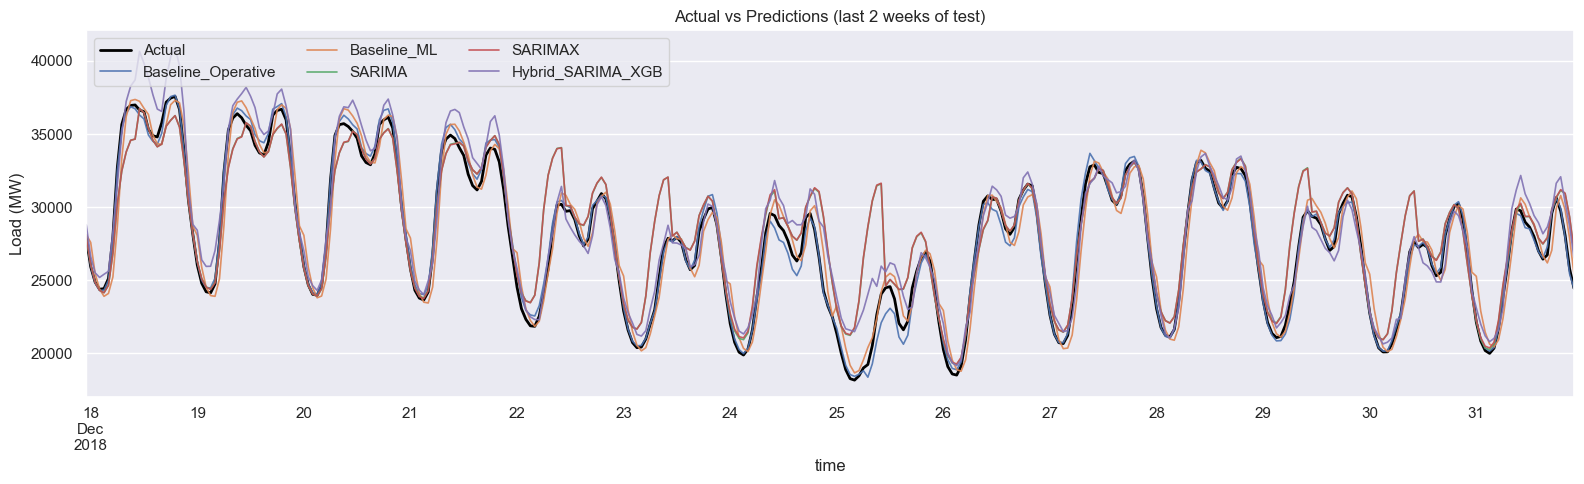

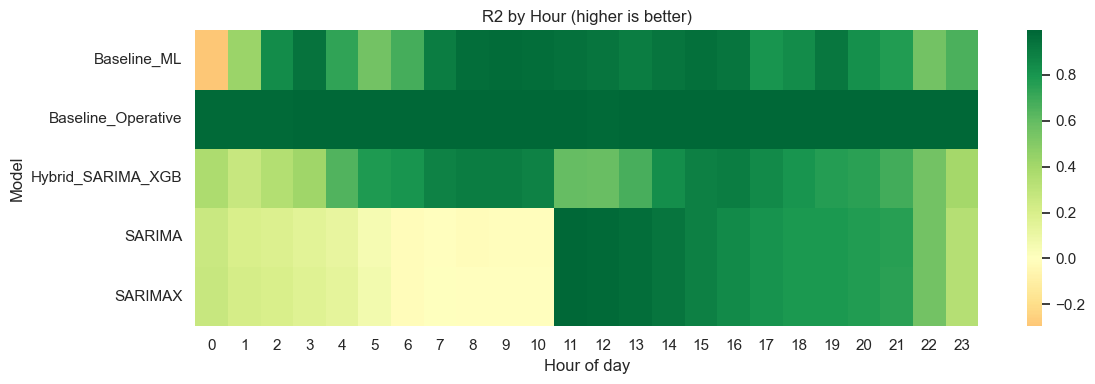

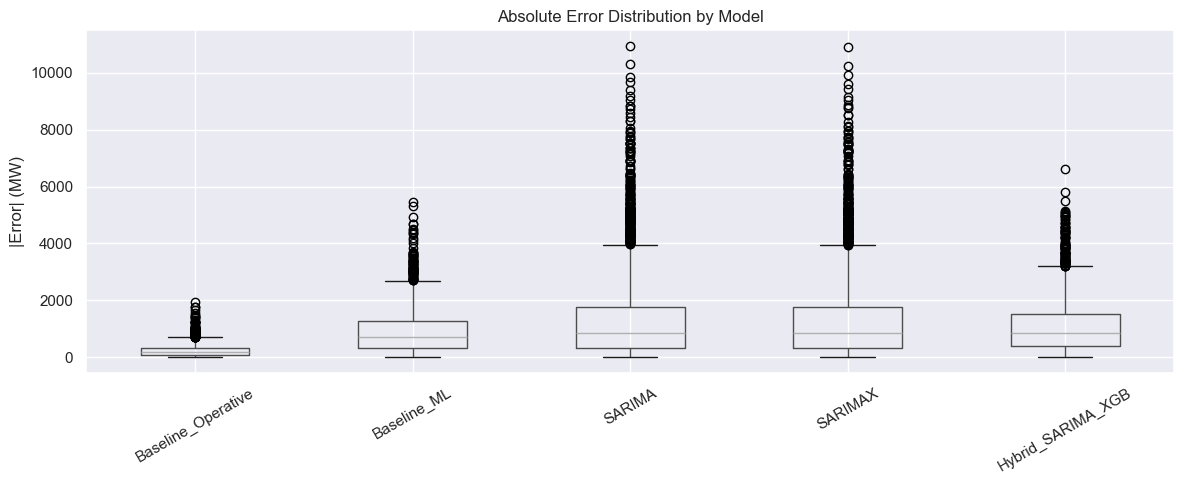

,model,R2,MASE,delta_vs_baseline_r2,MAE,RMSE,n_obs
1,Baseline_Operative,0.994797,0.097896,0.000000,243.145738,331.637253,2628
0,Baseline_ML,0.933771,0.362372,-0.061025,900.028652,1183.183639,2628
2,Hybrid_SARIMA_XGB,0.902403,0.437986,-0.092394,1087.832080,1436.308010,2628
4,SARIMAX,0.781502,0.567821,-0.213295,1410.304882,2149.085007,2628
3,SARIMA,0.780109,0.569431,-0.214688,1414.304480,2155.922582,2628


In [34]:
global_metrics_raw = pd.concat(results_global, ignore_index=True)
hourly_metrics_raw = pd.concat(results_hourly, ignore_index=True)

# Keep the latest result per model so reruns do not duplicate rows
if not global_metrics_raw.empty:
    global_metrics = global_metrics_raw.groupby("model", as_index=False).last()
else:
    global_metrics = global_metrics_raw

# Keep the latest metric per (model, hour) so pivot remains valid
if not hourly_metrics_raw.empty:
    hourly_metrics = hourly_metrics_raw.groupby(["model", "hour"], as_index=False).last()
else:
    hourly_metrics = hourly_metrics_raw

print("Global ranking by R2")
display(global_metrics.sort_values("R2", ascending=False))

hourly_r2_matrix = hourly_metrics.pivot(index="hour", columns="model", values="R2").sort_index()
display(hourly_r2_matrix)

# Plot 1: Actual vs predictions (last 2 weeks of test)
plot_window = 24 * 14
actual_plot = y_test.tail(plot_window)

fig, ax = plt.subplots(figsize=(16, 5))
actual_plot.plot(ax=ax, linewidth=2, color="black", label="Actual")
for model_name, pred in predictions.items():
    pred.reindex(actual_plot.index).plot(ax=ax, linewidth=1.2, alpha=0.9, label=model_name)
ax.set_title("Actual vs Predictions (last 2 weeks of test)")
ax.set_ylabel("Load (MW)")
ax.legend(loc="upper left", ncol=3)
plt.tight_layout()
plt.show()

# Plot 2: R2 by hour heatmap
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(hourly_r2_matrix.T, cmap="RdYlGn", center=0, ax=ax)
ax.set_title("R2 by Hour (higher is better)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Model")
plt.tight_layout()
plt.show()

# Plot 3: Distribution of absolute error by model
error_df = pd.DataFrame(index=y_test.index)
for model_name, pred in predictions.items():
    error_df[model_name] = (y_test - pred.reindex(y_test.index)).abs()

fig, ax = plt.subplots(figsize=(12, 5))
error_df.boxplot(ax=ax, rot=30)
ax.set_title("Absolute Error Distribution by Model")
ax.set_ylabel("|Error| (MW)")
plt.tight_layout()
plt.show()

# Plot 4: Improvement vs operative baseline in global R2
baseline_r2 = global_metrics.loc[global_metrics["model"] == "Baseline_Operative", "R2"].iloc[0]
comparison = global_metrics.copy()
comparison["delta_vs_baseline_r2"] = comparison["R2"] - baseline_r2
comparison = comparison.sort_values("delta_vs_baseline_r2", ascending=False)

cols = ["model", "R2", "MASE", "delta_vs_baseline_r2", "MAE", "RMSE", "n_obs"]
cols = [c for c in cols if c in comparison.columns]
display(comparison[cols])

## 10. Persist Model and Preprocessing Pipeline

Save baseline artifacts and provide a quick inference example.

In [27]:
import joblib
from pathlib import Path

artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

baseline_ml_path = artifacts_dir / "baseline_ml_pipeline.joblib"
joblib.dump(baseline_ml, baseline_ml_path)

print("Saved:", baseline_ml_path)

# Quick inference example
loaded_baseline = joblib.load(baseline_ml_path)
sample_pred = loaded_baseline.predict(X_test.head(5))

inference_preview = pd.DataFrame(
    {
        "timestamp": X_test.head(5).index,
        "y_true": y_test.head(5).values,
        "y_pred_baseline_ml": sample_pred,
    }
)

display(inference_preview)

Saved: artifacts\baseline_ml_pipeline.joblib


,timestamp,y_true,y_pred_baseline_ml
0,2018-09-13 11:00:00+00:00,35567.0,34473.892832
1,2018-09-13 12:00:00+00:00,34743.0,34451.221422
2,2018-09-13 13:00:00+00:00,34343.0,33252.126794
3,2018-09-13 14:00:00+00:00,34414.0,32637.570954
4,2018-09-13 15:00:00+00:00,34431.0,32630.253866


## 11. Results and Conclusion

### Models evaluated in this run

- Operational baseline: total load forecast (dataset)
- ML baseline: Linear Regression with preprocessing pipeline
- SARIMA: SARIMA(2,1,2)(1,1,1,24) with rolling evaluation
- SARIMAX: SARIMAX(2,1,2)(1,1,1,24) with exogenous variables (weather + calendar + generation)
- Hybrid (improved): SARIMA + XGBoost residual correction with validation-calibrated blending (alpha = 1.10)
- TimeXer: not included in this result table (no final prediction series stored in the current run)

### Consolidated metrics

| Model | R2 | MASE | MAE | RMSE | n_obs |
|---|---:|---:|---:|---:|---:|
| Baseline_Operative | 0.994797 | 0.097896 | 243.145738 | 331.637253 | 2628 |
| Baseline_ML | 0.933771 | 0.362372 | 900.028652 | 1183.183639 | 2628 |
| Hybrid_SARIMA_XGB | 0.902403 | 0.437986 | 1087.832080 | 1436.308010 | 2628 |
| SARIMAX | 0.781502 | 0.567821 | 1410.304882 | 2149.085007 | 2628 |
| SARIMA | 0.780109 | 0.569431 | 1414.304480 | 2155.922582 | 2628 |

### Ranking by R2 (best to worst)

1. Baseline_Operative
2. Baseline_ML
3. Hybrid_SARIMA_XGB
4. SARIMAX
5. SARIMA

### Interpretation

- The improved hybrid now clearly outperforms SARIMA and SARIMAX.
- The operational baseline and ML baseline are still stronger in this setup.
- Calibrating residual intensity on validation reduced over-correction and improved hybrid stability across hours.
- By MASE, lower is better, and the same ranking trend is preserved in this run.